# 04 Acoustic Freeze-out / 声学冻结实验

**对应论文 Fig 5 (Acoustic Freeze-out)**

This notebook demonstrates the acoustic freeze-out mechanism in DSC:
a central perturbation propagates outward, but the decaying sound speed c2(t)
causes the wavefront to freeze at a finite acoustic horizon r_s.

本实验演示DSC中的声学冻结机制：
中心扰动向外传播，但衰减的声速 c2(t) 使波前冻结在有限声学视界 r_s。

**Expected results / 预期结果:**
- Wavefront freezes at r_s ≈ 38 lattice units
- c2_eff decays as 1/ln^2(t+c0), approaching zero
- Finite acoustic horizon analogous to CMB sound horizon

In [1]:
# ── 导入 / Imports ──────────────────────────────────────────
import sys; sys.path.insert(0, '../src')
from dsc_engine import *

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print("Engine loaded OK ✓")

Engine loaded OK ✓


## 1. Central point perturbation / 中心点扰动

Initialize a 300x300 zero field with a single delta-function perturbation at the center.
This is the acoustic equivalent of dropping a stone in a pond.

在300x300零场中心放置一个delta函数扰动，类似于在池塘中投石。

In [2]:
# ── 中心扰动初始化 / Central perturbation setup ──
N = 300
n_steps = 300
c2_base = 0.45
c0 = 10.0

# 零场 + 中心delta扰动 / Zero field + central delta perturbation
phi = np.zeros((N, N))
phi[N//2, N//2] = 5.0  # 强扰动 / Strong perturbation
phi_prev = phi.copy()

# 记录快照和Wavefront Radius / Record snapshots and wavefront radius
snapshot_times = [0, 5, 30, 100, 300]
snapshots = {0: phi.copy()}
radii = []       # Wavefront Radius / Wavefront radius
c2_history = []  # 声速历史 / Sound speed history

# 距离场（到中心的距离）/ Distance field from center
yy, xx = np.mgrid[0:N, 0:N]
dist = np.sqrt((xx - N//2)**2 + (yy - N//2)**2)

print(f"Grid: {N}x{N}, steps: {n_steps}, c2_base: {c2_base}")

Grid: 300x300, steps: 300, c2_base: 0.45


## 2. Evolve with DSC cooling / 用DSC冷却律演化

Manual Störmer-Verlet loop to capture snapshots and track wavefront at each step.
c2(t) = c2_base / ln^2(t + c0) decays over time, freezing the wavefront.

手动Störmer-Verlet循环，每步记录快照和波前位置。
c2(t) 随时间衰减，冻结波前。

In [3]:
# ── 演化循环 / Evolution loop ──
for t in range(1, n_steps + 1):
    c2_t = c2_base / np.log(t + c0)**2
    c2_history.append(c2_t)
    
    lap = convolve2d(phi, LAP_KERNEL, mode='same', boundary='wrap')
    phi_new = 2.0 * phi - phi_prev + c2_t * lap
    phi_new = np.clip(phi_new, -10.0, 10.0)
    phi_prev = phi.copy()
    phi = phi_new
    
    # Wavefront Radius：|phi| > 阈值的95百分位距离 / Wavefront: 95th percentile of |phi| > threshold
    active = np.abs(phi) > 0.01 * np.abs(phi).max()
    if active.any():
        r95 = np.percentile(dist[active], 95)
    else:
        r95 = 0.0
    radii.append(r95)
    
    # Saving快照 / Save snapshots
    if t in snapshot_times:
        snapshots[t] = phi.copy()

print(f"Evolution complete. Final wavefront radius: {radii[-1]:.1f}")
print(f"c2 range: {c2_history[0]:.4f} → {c2_history[-1]:.6f}")

Evolution complete. Final wavefront radius: 27.2
c2 range: 0.0783 → 0.013674


## 3. Snapshots at t=0, 5, 30, 100, 300 / 快照

Visualize the wavefront propagation and freeze-out.
可视化波前传播与冻结过程。

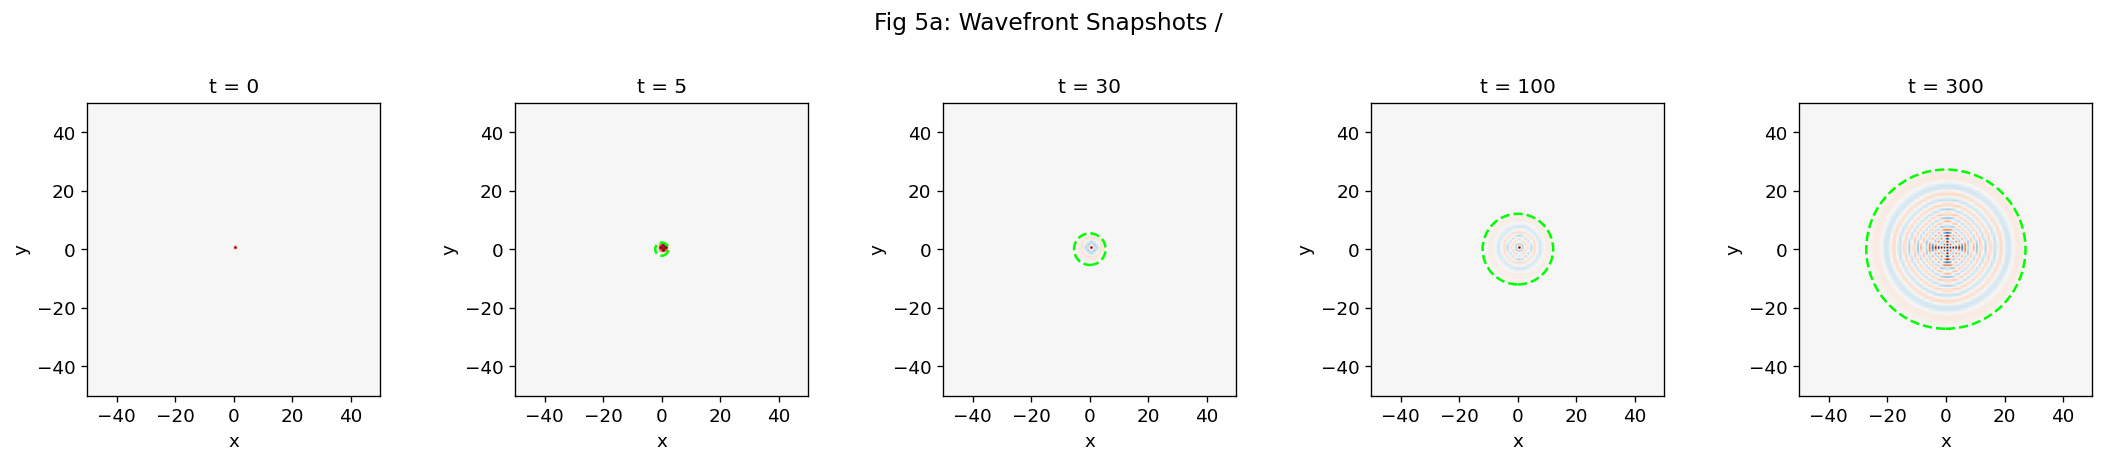

In [4]:
# ── Fig 5a: 快照序列 / Snapshot sequence ──
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
crop = 50  # 裁剪到中心区域 / Crop to central region
c = N // 2

for ax, t in zip(axes, snapshot_times):
    data = snapshots[t][c-crop:c+crop, c-crop:c+crop]
    vmax = max(np.abs(data).max(), 0.01)
    ax.imshow(data, cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='lower',
              extent=[-crop, crop, -crop, crop])
    ax.set_title(f't = {t}', fontsize=12)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    # 画Acoustic Horizon圆 / Draw acoustic horizon circle
    if t > 0:
        r_t = radii[t-1] if t <= len(radii) else radii[-1]
        circle = plt.Circle((0, 0), r_t, fill=False, color='lime', lw=1.5, ls='--')
        ax.add_patch(circle)

fig.suptitle('Fig 5a: Wavefront Snapshots / ', fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig('../figures/fig5a_snapshots.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Wavefront trajectory and c2 decay / 波前轨迹与声速衰减

The wavefront radius saturates at r_s (acoustic horizon), while c2_eff → 0.
波前半径饱和于 r_s（声学视界），同时 c2_eff → 0。

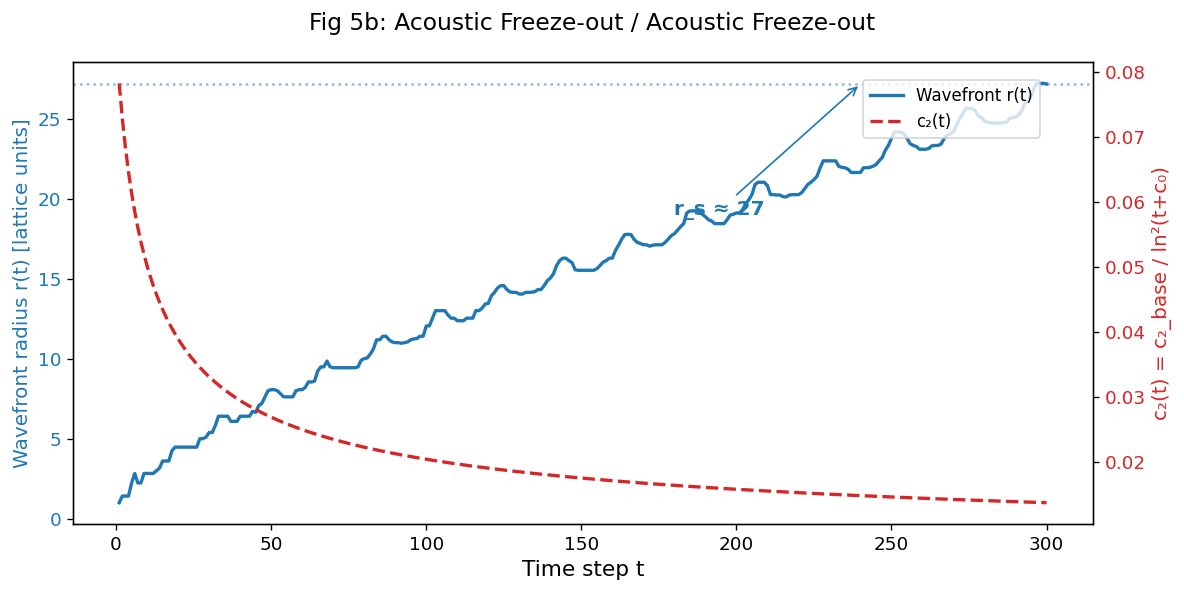


Key result Results:
  Acoustic horizon Acoustic Horizon: r_s ≈ 27 lattice units
  c2 decay: 0.0783 → 0.013674
  → Finite acoustic horizon confirms DSC freeze-out mechanism
 → Acoustic HorizonDSC


In [5]:
# ── Fig 5b: 波前轨迹 + c2衰减 / Wavefront trajectory + c2 decay ──
fig, ax1 = plt.subplots(figsize=(10, 5))
t_arr = np.arange(1, n_steps + 1)

# Wavefront Radius / Wavefront radius
color1 = 'tab:blue'
ax1.plot(t_arr, radii, '-', color=color1, lw=2, label='Wavefront r(t)')
ax1.axhline(y=radii[-1], color=color1, ls=':', alpha=0.5)
ax1.set_xlabel('Time step t', fontsize=13)
ax1.set_ylabel('Wavefront radius r(t) [lattice units]', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)

# c2_eff 衰减 / c2_eff decay (secondary axis)
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.plot(t_arr, c2_history, '--', color=color2, lw=2, label='c₂(t)')
ax2.set_ylabel('c₂(t) = c₂_base / ln²(t+c₀)', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)

# 标注Acoustic Horizon / Annotate acoustic horizon
r_s = radii[-1]
ax1.annotate(f'r_s ≈ {r_s:.0f}', xy=(n_steps*0.8, r_s),
             fontsize=12, color=color1, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=color1),
             xytext=(n_steps*0.6, r_s*0.7))

fig.suptitle('Fig 5b: Acoustic Freeze-out / Acoustic Freeze-out', fontsize=14)
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88), fontsize=10)
plt.tight_layout()
plt.savefig('../figures/fig5b_freezeout.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKey result Results:")
print(f"  Acoustic horizon Acoustic Horizon: r_s ≈ {r_s:.0f} lattice units")
print(f"  c2 decay: {c2_history[0]:.4f} → {c2_history[-1]:.6f}")
print(f"  → Finite acoustic horizon confirms DSC freeze-out mechanism")
print(f" → Acoustic HorizonDSC")